## Problem 2 - SOFM

In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import random

In [2]:
labels = []
numbers = []

with open(os.path.join(os.getcwd(), 'data/MNISTnumLabels5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        labels.append(int(line))

with open(os.path.join(os.getcwd(), 'data/MNISTnumImages5000_balanced.txt'), 'r+') as f:
    lines = f.readlines()
    for line in lines:
        ind_line = line.split('\t')
        ind_line = [float(i) for i in ind_line]

        numbers.append(ind_line)
    

labels = np.array(labels)
numbers = np.array(numbers)

8


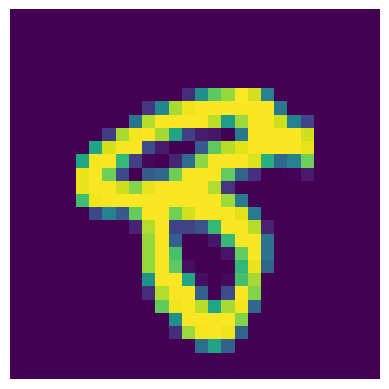

In [3]:
index = random.randint(0, 4999)

example_number = numbers[index]
example_label = labels[index]
matrix = example_number.reshape(28, 28).T

print(example_label)
plt.imshow(matrix)
plt.axis('off')
plt.show()

In [4]:
train_set = []
train_labels = []

test_set = []
test_labels = []

digits = {d: 0 for d in range(0, 10)}

for i in range(len(numbers)):
    label = labels[i]  # get the digit for this image
    
    if label in digits and digits[label] < 400:
        train_set.append(numbers[i])
        train_labels.append(label)
        digits[label] += 1
    else:
        test_set.append(numbers[i])
        test_labels.append(label)
        digits[label] += 1


train_set = np.array(train_set)
test_set = np.array(test_set)
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)
# normalizing the datasets
train_set = train_set.astype(np.float32)/255.0
test_set = test_set.astype(np.float32)/255.0

combined_train_data = list(zip(train_labels, train_set))
random.shuffle(combined_train_data)

combined_test_data = list(zip(test_labels, test_set))
random.shuffle(combined_test_data)

print(len(combined_train_data), len(combined_test_data))

4000 1000


In [5]:
m, n = train_set.shape

X_train, X_test = train_set, test_set
Y_train, Y_test = train_labels, test_labels

_, m_train = X_train.shape
_, m_test = X_test.shape

In [6]:
# Shuffle training set
perm_train = np.random.permutation(X_train.shape[0])  # columns = samples
X_train = X_train[perm_train]
Y_train = np.array(Y_train)[perm_train]  

# Shuffle test set
perm_test = np.random.permutation(X_test.shape[0])
X_test = X_test[perm_test]
Y_test = np.array(Y_test)[perm_test]

X_train.shape, Y_train.shape

((4000, 784), (4000,))

### SOFM Implementation

In [7]:
class SOFM:
    def __init__(self, map_size=(12, 12), input_dim=784, alpha0=0.01, sigma0=5, epochs=100):
        self.rows, self.cols = map_size
        self.num_neurons = self.rows * self.cols
        self.input_dim = input_dim

        # Learning parameters
        self.alpha0 = alpha0
        self.sigma0 = sigma0
        self.epochs = epochs

        # Initialize random weights
        self.W = np.random.rand(self.num_neurons, self.input_dim)

        # Store neuron (row, col) positions
        self.positions = np.array([(i // self.cols, i % self.cols) for i in range(self.num_neurons)])

    
    ### Helper Functions ###

    # Returns the index of the best matching neuron for input X
    # Uses euclidian distance
    def find_bmu(self, x):
        distances = np.linalg.norm(self.W - x, axis=1)
        return np.argmin(distances)

    # Compute neighborhood influence on all neurons
    # This helps the map gain a smooth organized layout,
    # Where similar inputs activate neighboring neurons instead of
    # random spots
    def neighborhood_influence(self, bmu_idx, sigma):
        bmu_pos = self.positions[bmu_idx]
        dists = np.linalg.norm(self.positions - bmu_pos, axis=1)
        return np.exp(-(dists ** 2) / (2 * (sigma ** 2)))


    ### Training Function ###

    def train(self, train_data):
        for epoch in range(self.epochs):
            # Decay learning rate + neighborhood radius
            alpha = self.alpha0 * np.exp(-epoch / self.epochs)
            sigma = self.sigma0 * np.exp(-epoch / self.epochs)

            print(f"Epoch {epoch+1}/{self.epochs} — alpha={alpha:.4f}, sigma={sigma:.4f}")

            # Shuffle training set for better training
            np.random.shuffle(train_data)

            for x in train_data:
                bmu = self.find_bmu(x)
                h = self.neighborhood_influence(bmu, sigma)   # shape (num_neurons,)

                # Update all neurons
                self.W += (alpha * h[:, np.newaxis]) * (x - self.W)

    
    ### Testing / Activity Maps ###
    def test(self, test_data, test_labels):
        class_activity = np.zeros((10, self.num_neurons))  # 10 classes

        for x, label in zip(test_data, test_labels):
            bmu = self.find_bmu(x)
            class_activity[label, bmu] += 1

        # Convert counts → fractions (each digit has 100 samples)
        return class_activity / 100.0
    
    ##    Plot 10 heatmaps (12×12) for classes 0–9.
    ##    Input: class_activity of shape (10, num_neurons)
    def plot_activity_maps(self, class_activity):
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))

        for c in range(10):
            ax = axes[c // 5, c % 5]
            heatmap = class_activity[c].reshape(self.rows, self.cols)
            im = ax.imshow(heatmap, cmap='hot', interpolation='nearest')
            ax.set_title(f"Class {c}")
            ax.axis('off')

        plt.tight_layout()
        plt.show()


    ##    Plot the 12×12 grid of 28×28 neuron weight images.
    ##    Final image dimension = 336×336 (as required by assignment).
    def plot_weight_grid(self):
        fig, axes = plt.subplots(self.rows, self.cols, figsize=(10, 10))

        for i in range(self.num_neurons):
            r, c = i // self.cols, i % self.cols
            ax = axes[r, c]
            ax.imshow(self.W[i].reshape(28, 28), cmap='gray')
            ax.axis('off')

        plt.tight_layout()
        plt.show()
        


### Training and Testing Performance

In [8]:
som = SOFM(epochs=100, sigma0=6, alpha0=0.1)

som.train(X_train)

Epoch 1/100 — alpha=0.1000, sigma=6.0000
Epoch 2/100 — alpha=0.0990, sigma=5.9403
Epoch 3/100 — alpha=0.0980, sigma=5.8812
Epoch 4/100 — alpha=0.0970, sigma=5.8227
Epoch 5/100 — alpha=0.0961, sigma=5.7647
Epoch 6/100 — alpha=0.0951, sigma=5.7074
Epoch 7/100 — alpha=0.0942, sigma=5.6506
Epoch 8/100 — alpha=0.0932, sigma=5.5944
Epoch 9/100 — alpha=0.0923, sigma=5.5387
Epoch 10/100 — alpha=0.0914, sigma=5.4836
Epoch 11/100 — alpha=0.0905, sigma=5.4290
Epoch 12/100 — alpha=0.0896, sigma=5.3750
Epoch 13/100 — alpha=0.0887, sigma=5.3215
Epoch 14/100 — alpha=0.0878, sigma=5.2686
Epoch 15/100 — alpha=0.0869, sigma=5.2161
Epoch 16/100 — alpha=0.0861, sigma=5.1642
Epoch 17/100 — alpha=0.0852, sigma=5.1129
Epoch 18/100 — alpha=0.0844, sigma=5.0620
Epoch 19/100 — alpha=0.0835, sigma=5.0116
Epoch 20/100 — alpha=0.0827, sigma=4.9618
Epoch 21/100 — alpha=0.0819, sigma=4.9124
Epoch 22/100 — alpha=0.0811, sigma=4.8635
Epoch 23/100 — alpha=0.0803, sigma=4.8151
Epoch 24/100 — alpha=0.0795, sigma=4.7672
E

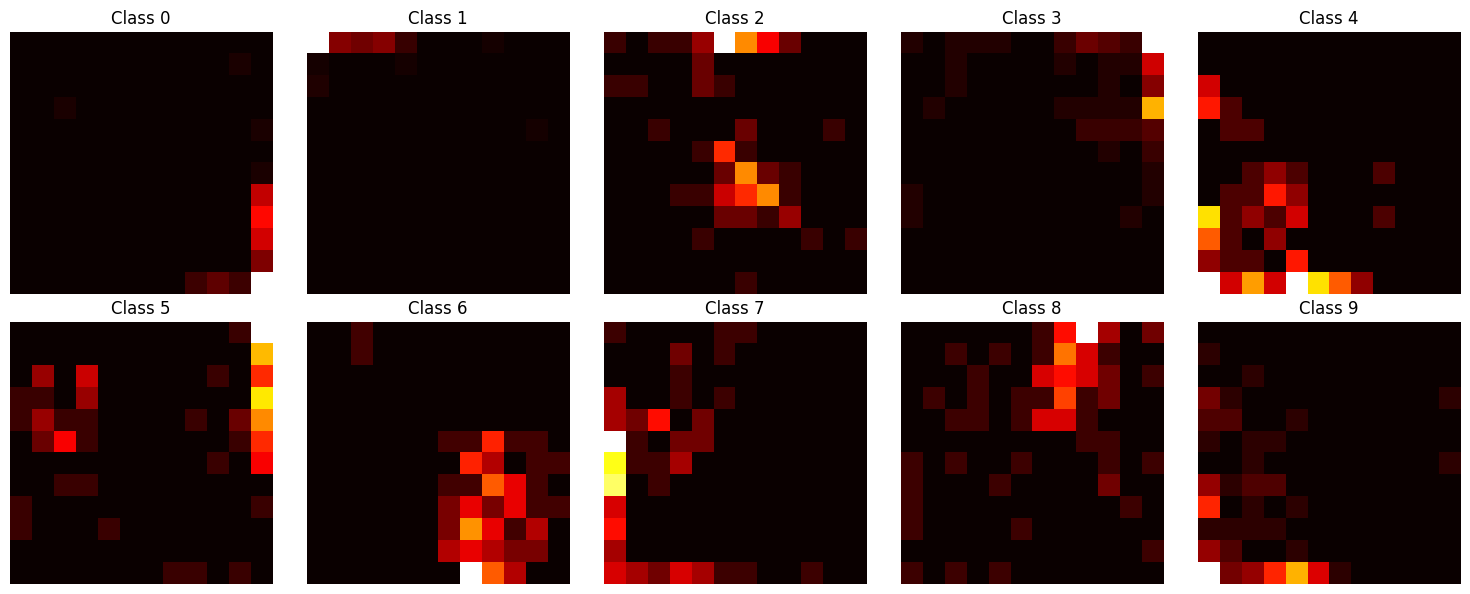

In [9]:
class_activity = som.test(X_test, Y_test)
som.plot_activity_maps(class_activity)

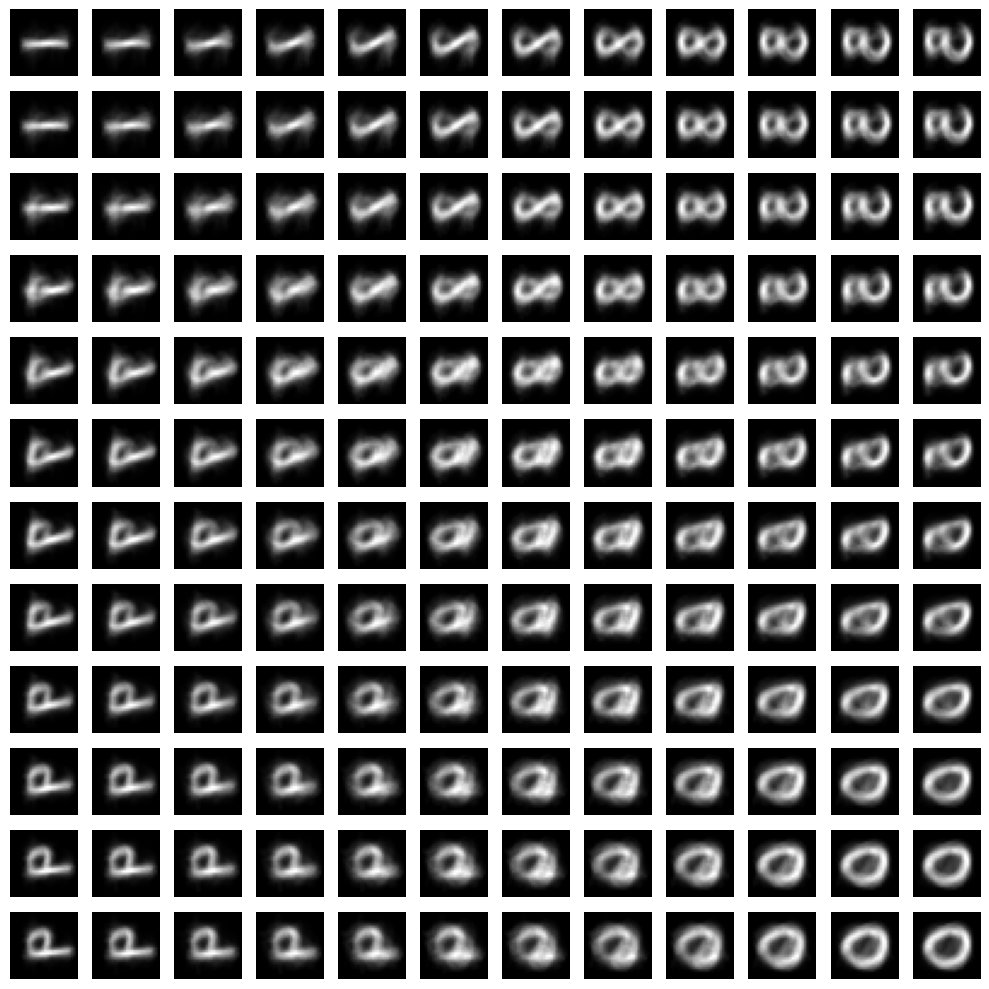

In [10]:
som.plot_weight_grid()

## Problem 3 - SOFM + Sigmoid

In [ ]:
# I feel like the issue HAS to be here
# Like I don't think the bmu index + sigmoid is mapping the
# 10 feature matrix properly.
import numpy as np
import matplotlib.pyplot as plt

class OutputLayer:
    def __init__(self, sofm, lr=0.1, momentum=0.9, sigma_out=2.0):
        self.sofm = sofm
        self.lr = lr
        self.momentum = momentum
        self.sigma_out = sigma_out  # neighborhood radius for output features
        
        # Weight shape: (num_neurons, 10) - each neuron votes for each class
        self.W_out = np.random.randn(self.sofm.num_neurons, 10) * 0.01
        self.b_out = np.zeros(10)
        
        self.dW_prev = np.zeros_like(self.W_out)
        self.db_prev = np.zeros_like(self.b_out)

        
    
    def compute_feature_vector(self, x):
        """
        Compute distributed feature vector using Gaussian activation
        around the BMU (similar to SOFM training).
        """
        bmu = self.sofm.find_bmu(x)
        bmu_pos = self.sofm.positions[bmu]
        
        # Calculate distances from BMU to all neurons
        dists = np.linalg.norm(self.sofm.positions - bmu_pos, axis=1)
        
        # Gaussian activation (like neighborhood influence in SOFM)
        phi = np.exp(-(dists ** 2) / (2 * (self.sigma_out ** 2)))
        
        # Normalize to sum to 1 (optional but helps stability)
        phi = phi / np.sum(phi)
        
        return phi
    
    def classifier_forward(self, features):
        """
        Forward pass with sigmoid activation.
        features: (num_neurons,)
        W_out: (num_neurons, 10)
        output: (10,)
        """
        logits = features @ self.W_out + self.b_out  # (10,)
        probs = 1 / (1 + np.exp(-logits))  # sigmoid
        return probs
    
    def train_classifier(self, train_data, train_labels, test_data, test_labels, epochs=20):
        train_err_hist = []
        test_err_hist = []
        
        for epoch in range(epochs):
            # Shuffle training data
            indices = np.random.permutation(len(train_data))
            
            for idx in indices:
                x, y = train_data[idx], train_labels[idx]
                
                # Forward pass
                phi = self.compute_feature_vector(x)  # (num_neurons,)
                probs = self.classifier_forward(phi)  # (10,)
                
                # One-hot target
                t = np.zeros(10)
                t[y] = 1
                
                # Compute error (gradient of cross-entropy with sigmoid)
                error = probs - t  # (10,)
                
                # Compute gradients
                grad_W = np.outer(phi, error)  # (num_neurons, 10)
                grad_b = error  # (10,)
                
                # Update with momentum
                dW = self.lr * grad_W + self.momentum * self.dW_prev
                db = self.lr * grad_b + self.momentum * self.db_prev
                
                self.W_out -= dW
                self.b_out -= db
                
                # Store for momentum
                self.dW_prev = dW
                self.db_prev = db
            
            # Evaluate
            train_acc = self.evaluate(train_data, train_labels)
            test_acc = self.evaluate(test_data, test_labels)
            train_err_hist.append(1 - train_acc)
            test_err_hist.append(1 - test_acc)
            
            print(f"Epoch {epoch+1}/{epochs} | Train Acc = {train_acc:.3f} | Test Acc = {test_acc:.3f}")
        
        return train_err_hist, test_err_hist
    
    def predict(self, x):
        phi = self.compute_feature_vector(x)
        probs = self.classifier_forward(phi)
        return np.argmax(probs)
    
    def evaluate(self, data, labels):
        correct = 0
        for x, y in zip(data, labels):
            if self.predict(x) == y:
                correct += 1
        return correct / len(labels)
    
    def plot_output_weight_maps(self):
        """Plot the output weights reshaped to the SOFM grid."""
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        for j in range(10):
            ax = axes[j // 5, j % 5]
            # W_out is (num_neurons, 10), so we take column j
            heat = self.W_out[:, j].reshape(self.sofm.rows, self.sofm.cols)
            ax.imshow(heat, cmap="hot")
            ax.set_title(f"Class {j}")
            ax.axis('off')
        plt.tight_layout()
        plt.show()

In [ ]:
outputLayer = OutputLayer(sofm=som)

train_err_hist, test_err_hist = outputLayer.train_classifier(X_train, Y_train, X_test, Y_test, epochs=1000)

Epoch 1/100 | Train Acc = 0.100 | Test Acc = 0.100
Epoch 2/100 | Train Acc = 0.100 | Test Acc = 0.100
Epoch 3/100 | Train Acc = 0.100 | Test Acc = 0.100
Epoch 4/100 | Train Acc = 0.117 | Test Acc = 0.099
Epoch 5/100 | Train Acc = 0.103 | Test Acc = 0.100
Epoch 6/100 | Train Acc = 0.108 | Test Acc = 0.089
Epoch 7/100 | Train Acc = 0.100 | Test Acc = 0.100
Epoch 8/100 | Train Acc = 0.123 | Test Acc = 0.188
Epoch 9/100 | Train Acc = 0.102 | Test Acc = 0.097
Epoch 10/100 | Train Acc = 0.106 | Test Acc = 0.122
Epoch 11/100 | Train Acc = 0.103 | Test Acc = 0.094
Epoch 12/100 | Train Acc = 0.100 | Test Acc = 0.100
Epoch 13/100 | Train Acc = 0.117 | Test Acc = 0.084
Epoch 14/100 | Train Acc = 0.103 | Test Acc = 0.100
Epoch 15/100 | Train Acc = 0.100 | Test Acc = 0.100
Epoch 16/100 | Train Acc = 0.113 | Test Acc = 0.133
Epoch 17/100 | Train Acc = 0.105 | Test Acc = 0.134
Epoch 18/100 | Train Acc = 0.102 | Test Acc = 0.102
Epoch 19/100 | Train Acc = 0.106 | Test Acc = 0.095
Epoch 20/100 | Train 

KeyboardInterrupt: 

In [46]:
outputLayer.evaluate(X_test, Y_test)

0.121

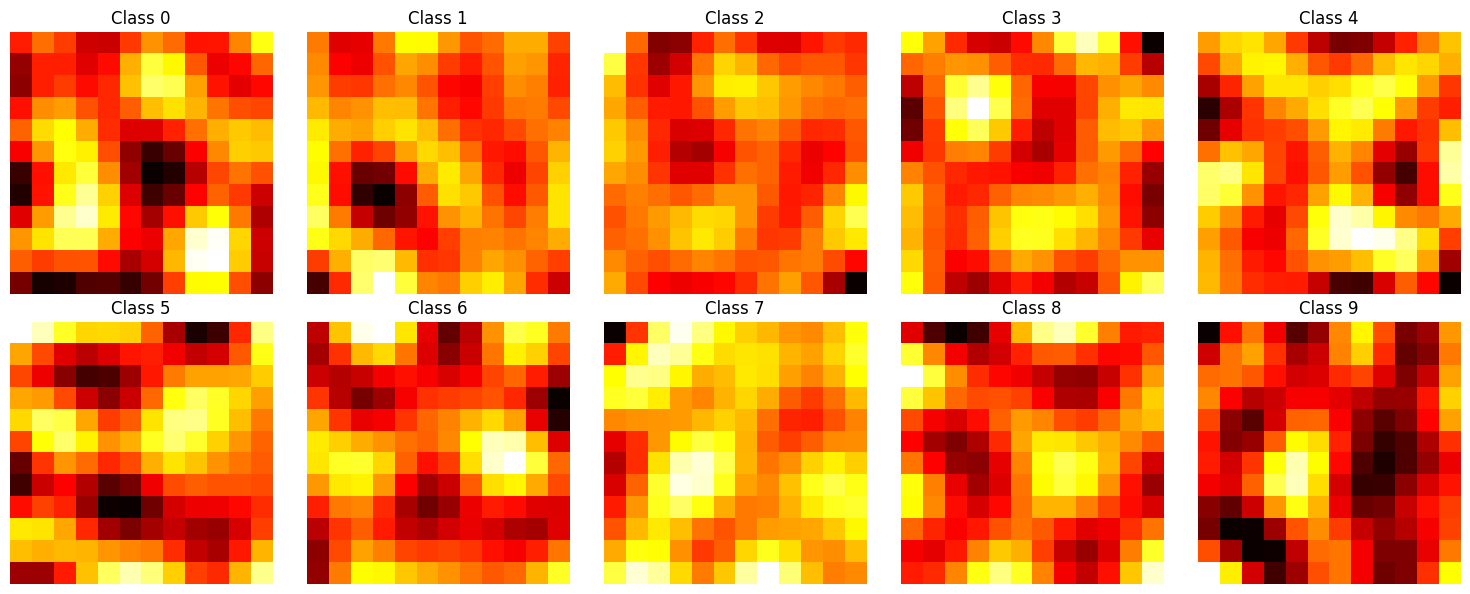

In [47]:
outputLayer.plot_output_weight_maps()

In [48]:
plt.plot(np.arange(0, 100), train_err_hist)

NameError: name 'train_err_hist' is not defined